Loaded: (230548, 35)

Metrics computed for 50 stocks
    ticker  annual_return  annual_vol  sharpe_ratio  sortino_ratio  max_drawdown  num_days
BAJAJFINSV       0.430168    0.369404      1.002067       1.517790     -0.585896      3002
  SHREECEM       0.408106    0.369343      0.942499       1.517954     -0.799734      4786
BAJFINANCE       0.429482    0.484187      0.763098       0.906839     -0.932820      5036
 EICHERMOT       0.392171    0.474374      0.700229       0.860049     -0.938237      5102
     TITAN       0.366874    0.499319      0.614585       0.742355     -0.966869      5107
INDUSINDBK       0.356392    0.490596      0.604147       0.874475     -0.851066      4786
ULTRACEMCO       0.246214    0.331732      0.561340       0.848812     -0.777797      3941
 KOTAKBANK       0.307697    0.486150      0.509507       0.570029     -0.845069      4786
 NESTLEIND       0.180797    0.242835      0.497445       0.780537     -0.324011      2607
ASIANPAINT       0.227963    0.341669

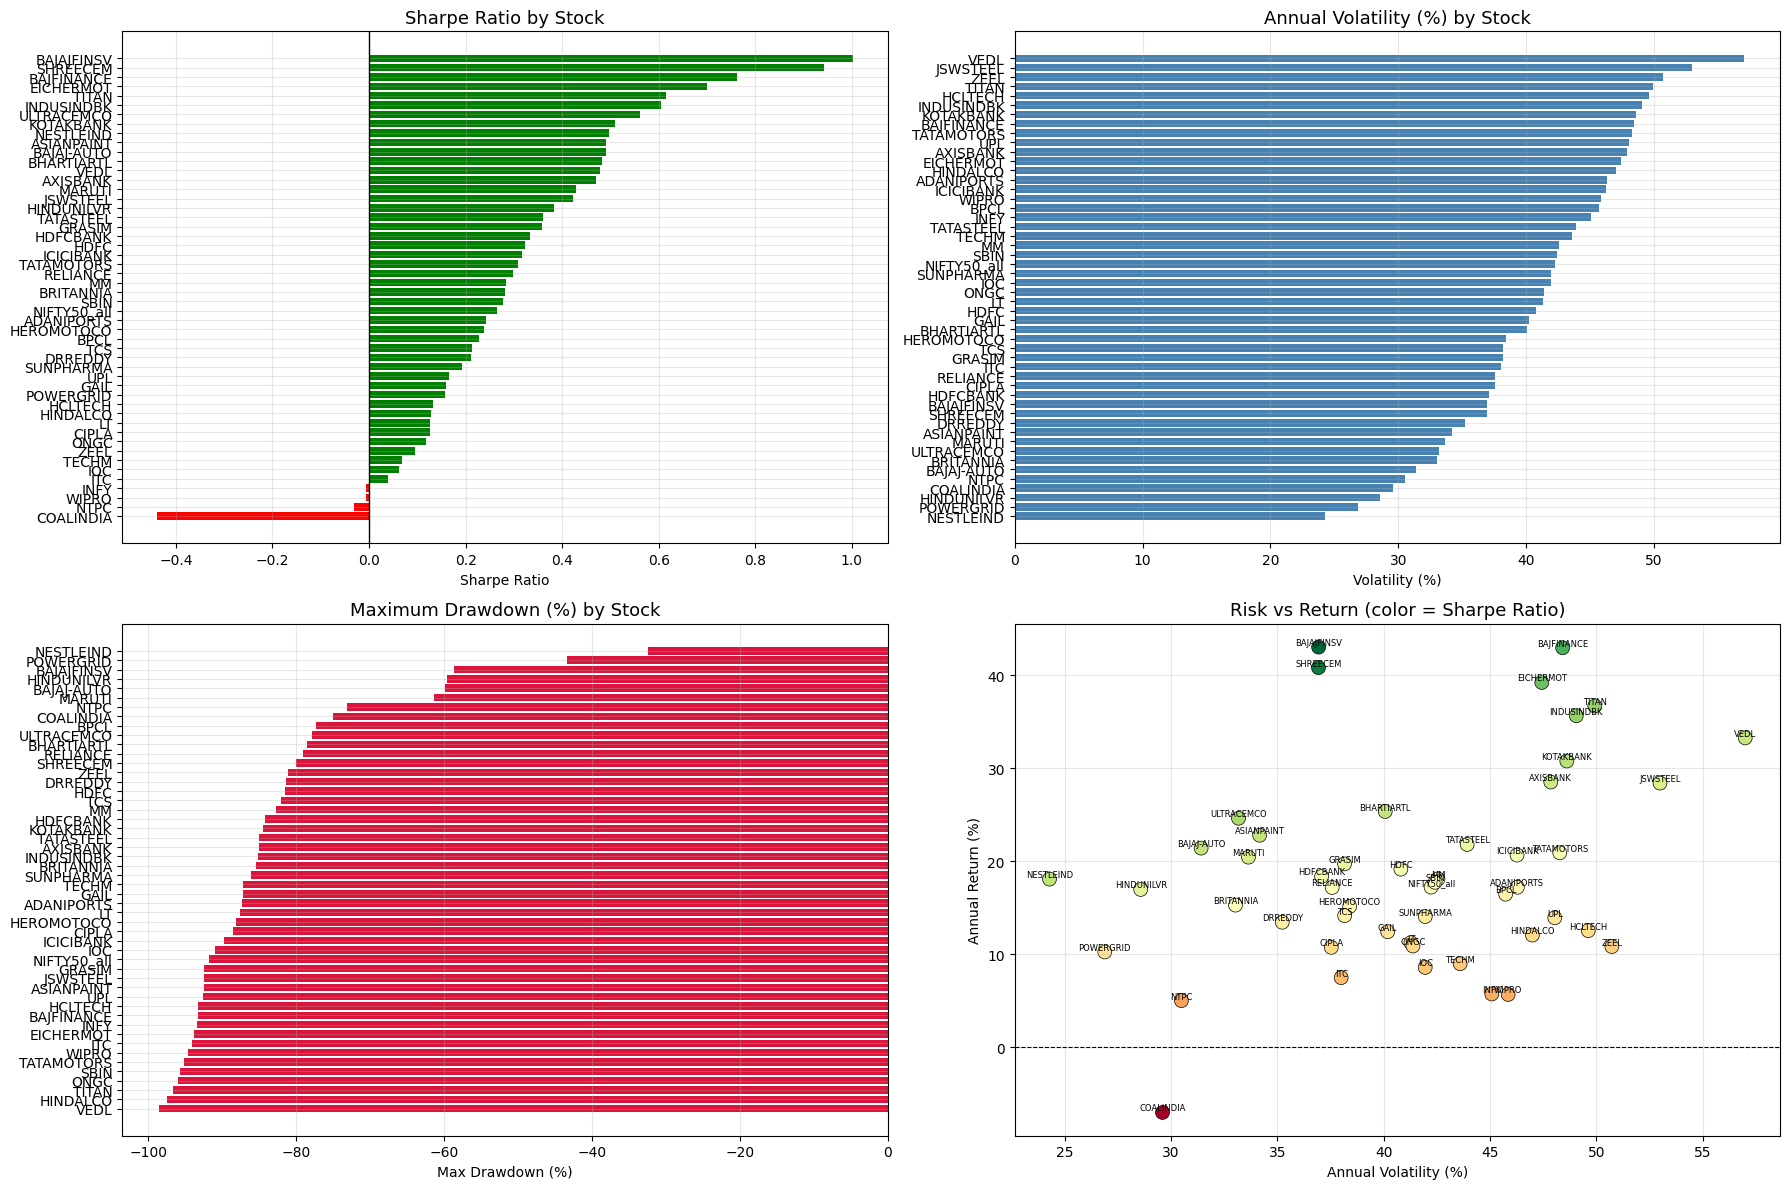

Risk plots saved ✅

=== CONSERVATIVE PORTFOLIO ===
    ticker   weight  annual_return  sharpe_ratio
ASIANPAINT 0.264413       0.227963      0.491596
  SHREECEM 0.180705       0.408106      0.942499
    GRASIM 0.120885       0.197141      0.359370
BAJFINANCE 0.108514       0.429482      0.763098
 EICHERMOT 0.103432       0.392171      0.700229
 BRITANNIA 0.096789       0.152854      0.281105
ULTRACEMCO 0.070657       0.246214      0.561340
     TITAN 0.054604       0.366874      0.614585

=== BALANCED PORTFOLIO ===
    ticker   weight  annual_return  sharpe_ratio
BAJAJFINSV 0.274660       0.430168      1.002067
  SHREECEM 0.243383       0.408106      0.942499
BAJFINANCE 0.152058       0.429482      0.763098
 EICHERMOT 0.117106       0.392171      0.700229
     TITAN 0.069491       0.366874      0.614585
INDUSINDBK 0.063802       0.356392      0.604147
ULTRACEMCO 0.044305       0.246214      0.561340
 NESTLEIND 0.015260       0.180797      0.497445
 KOTAKBANK 0.011339       0.307697     

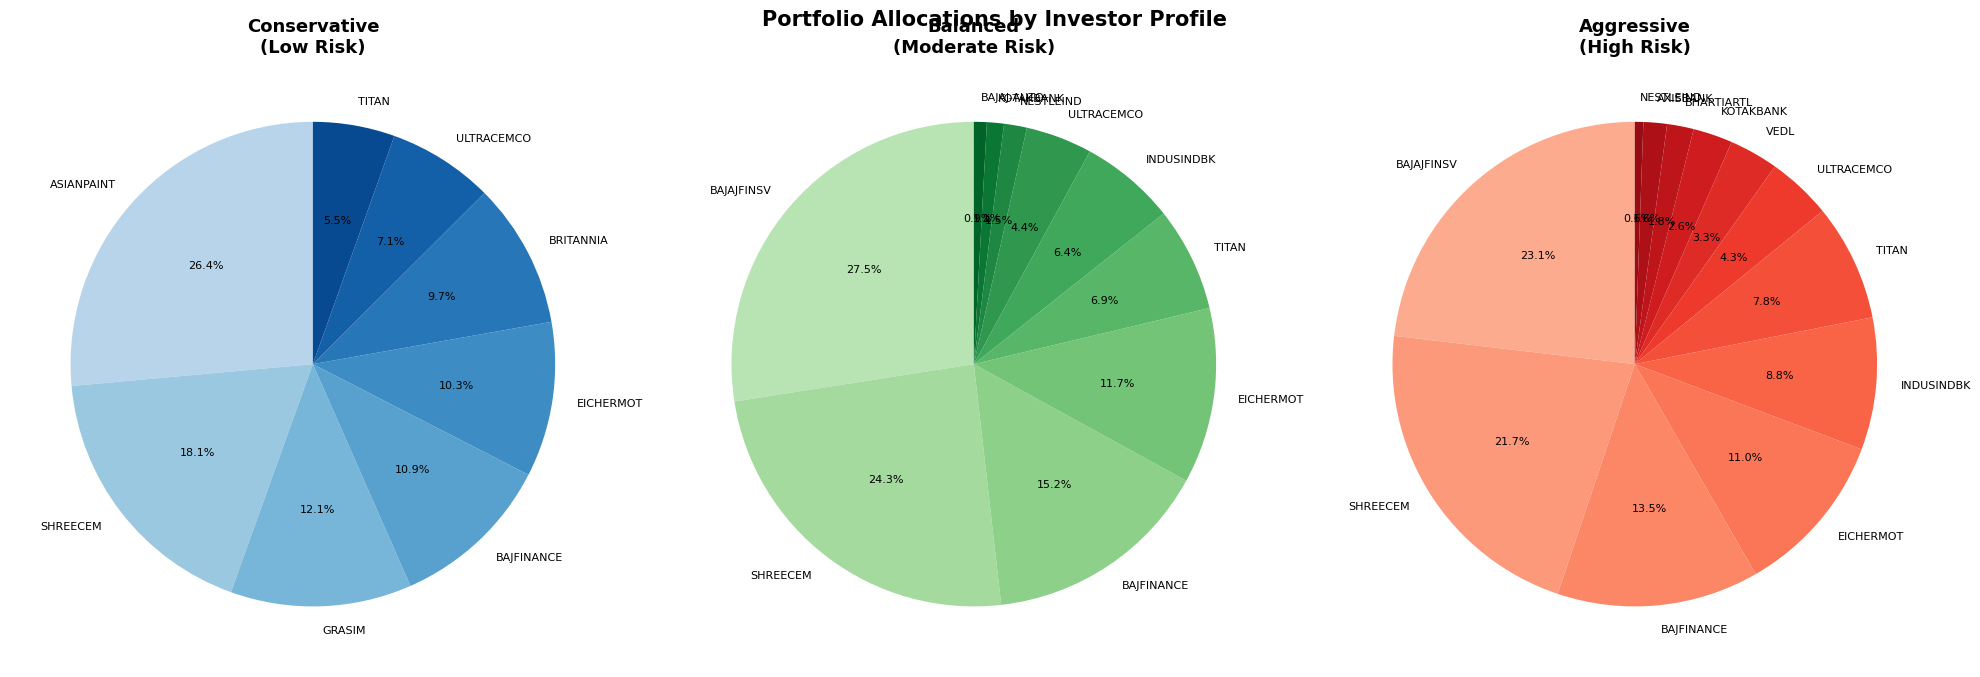

Portfolio charts saved ✅

=== PORTFOLIO SIMULATION ===

Conservative Portfolio:
  Total Return    : 716.1%
  Annual Return   : 24.5%
  Annual Volatility: 21.6%
  Sharpe Ratio    : 0.85
  Max Drawdown    : -40.8%

Balanced Portfolio:
  Total Return    : 1795.0%
  Annual Return   : 33.7%
  Annual Volatility: 23.5%
  Sharpe Ratio    : 1.18
  Max Drawdown    : -46.0%

Aggressive Portfolio:
  Total Return    : 1478.1%
  Annual Return   : 31.7%
  Annual Volatility: 23.1%
  Sharpe Ratio    : 1.11
  Max Drawdown    : -47.0%


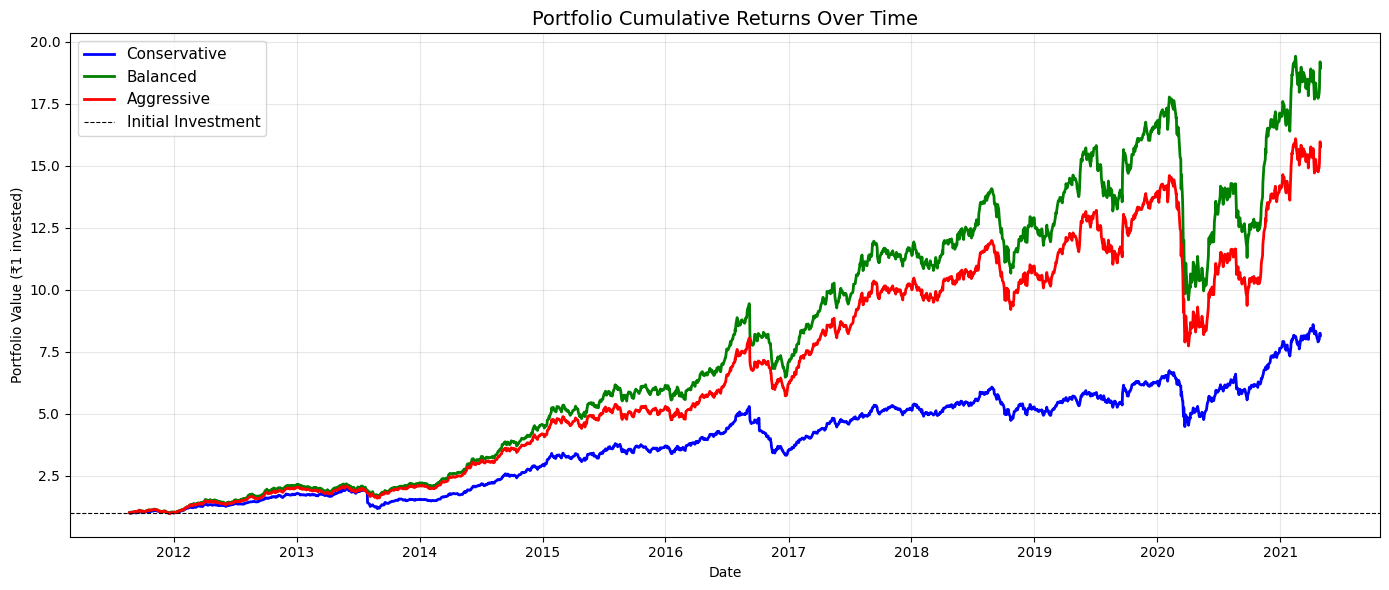

Performance chart saved ✅

All results saved ✅
PORTFOLIO + RISK MODULE DONE ✅


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

FEATURES_PATH = r"C:\Users\sarin\Downloads\nifty50_project\data\features_data.csv"
OUTPUT_FOLDER = r"C:\Users\sarin\Downloads\nifty50_project\outputs"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ── LOAD ──────────────────────────────────────────────────────
df = pd.read_csv(FEATURES_PATH, parse_dates=['date'])
df = df.sort_values(['ticker','date']).reset_index(drop=True)
print(f"Loaded: {df.shape}")

# ── STEP 1: COMPUTE PER-STOCK METRICS ─────────────────────────
def compute_stock_metrics(df):
    results = []
    for ticker in df['ticker'].unique():
        stock = df[df['ticker'] == ticker].copy()
        ret = stock['daily_return'].dropna()
        close = stock['close']

        if len(ret) < 50:
            continue

        # Annualised return & volatility
        annual_return = ret.mean() * 252
        annual_vol    = ret.std()  * np.sqrt(252)

        # Sharpe Ratio (risk-free = 6% for India)
        risk_free = 0.06
        sharpe = (annual_return - risk_free) / (annual_vol + 1e-10)

        # Sortino Ratio
        downside = ret[ret < 0].std() * np.sqrt(252)
        sortino  = (annual_return - risk_free) / (downside + 1e-10)

        # Max Drawdown
        cumulative  = (1 + ret).cumprod()
        rolling_max = cumulative.cummax()
        drawdown    = (cumulative - rolling_max) / (rolling_max + 1e-10)
        max_drawdown = drawdown.min()

        # Beta (vs equal-weight market)
        results.append({
            'ticker'        : ticker,
            'annual_return' : annual_return,
            'annual_vol'    : annual_vol,
            'sharpe_ratio'  : sharpe,
            'sortino_ratio' : sortino,
            'max_drawdown'  : max_drawdown,
            'num_days'      : len(ret)
        })

    return pd.DataFrame(results)

metrics_df = compute_stock_metrics(df)
print(f"\nMetrics computed for {len(metrics_df)} stocks")
print(metrics_df.sort_values('sharpe_ratio', ascending=False).head(10).to_string(index=False))

# ── STEP 2: RISK PLOTS ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Sharpe Ratio
sorted_sharpe = metrics_df.sort_values('sharpe_ratio', ascending=True)
colors = ['green' if x > 0 else 'red' for x in sorted_sharpe['sharpe_ratio']]
axes[0,0].barh(sorted_sharpe['ticker'], sorted_sharpe['sharpe_ratio'], color=colors)
axes[0,0].axvline(0, color='black', linewidth=1)
axes[0,0].set_title('Sharpe Ratio by Stock', fontsize=13)
axes[0,0].set_xlabel('Sharpe Ratio')
axes[0,0].grid(True, alpha=0.3)

# Volatility
sorted_vol = metrics_df.sort_values('annual_vol', ascending=True)
axes[0,1].barh(sorted_vol['ticker'], sorted_vol['annual_vol']*100, color='steelblue')
axes[0,1].set_title('Annual Volatility (%) by Stock', fontsize=13)
axes[0,1].set_xlabel('Volatility (%)')
axes[0,1].grid(True, alpha=0.3)

# Max Drawdown
sorted_dd = metrics_df.sort_values('max_drawdown', ascending=True)
axes[1,0].barh(sorted_dd['ticker'], sorted_dd['max_drawdown']*100, color='crimson')
axes[1,0].set_title('Maximum Drawdown (%) by Stock', fontsize=13)
axes[1,0].set_xlabel('Max Drawdown (%)')
axes[1,0].grid(True, alpha=0.3)

# Risk vs Return scatter
axes[1,1].scatter(metrics_df['annual_vol']*100,
                  metrics_df['annual_return']*100,
                  c=metrics_df['sharpe_ratio'], cmap='RdYlGn',
                  s=100, edgecolors='black', linewidth=0.5)
for _, row in metrics_df.iterrows():
    axes[1,1].annotate(row['ticker'],
                       (row['annual_vol']*100, row['annual_return']*100),
                       fontsize=6, ha='center', va='bottom')
axes[1,1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,1].set_xlabel('Annual Volatility (%)')
axes[1,1].set_ylabel('Annual Return (%)')
axes[1,1].set_title('Risk vs Return (color = Sharpe Ratio)', fontsize=13)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'risk_metrics.png'), dpi=150)
plt.show()
print("Risk plots saved ✅")

# ── STEP 3: PORTFOLIO CONSTRUCTION ────────────────────────────
def build_portfolio(metrics_df, profile='balanced'):
    df = metrics_df.copy()

    if profile == 'conservative':
        # Low volatility + positive return + low drawdown
        df['score'] = (
            -df['annual_vol'] * 0.5 +
             df['annual_return'] * 0.2 +
            -df['max_drawdown'] * 0.3
        )
        top_n = 8

    elif profile == 'balanced':
        # Best Sharpe ratio stocks
        df['score'] = (
            df['sharpe_ratio'] * 0.5 +
            df['annual_return'] * 0.3 +
           -df['annual_vol']   * 0.2
        )
        top_n = 10

    elif profile == 'aggressive':
        # Highest return, accept high risk
        df['score'] = (
            df['annual_return'] * 0.6 +
            df['sharpe_ratio']  * 0.2 +
            df['sortino_ratio'] * 0.2
        )
        top_n = 12

    # Pick top N
    selected = df.nlargest(top_n, 'score').copy()

    # Equal weight then normalize
    selected['raw_weight'] = 1.0 / top_n

    # Adjust weight by score (proportional)
    selected['score_shifted'] = selected['score'] - selected['score'].min() + 0.01
    selected['weight'] = selected['score_shifted'] / selected['score_shifted'].sum()
    selected['profile'] = profile

    return selected[['ticker','weight','annual_return','annual_vol',
                      'sharpe_ratio','max_drawdown','profile']]

conservative = build_portfolio(metrics_df, 'conservative')
balanced     = build_portfolio(metrics_df, 'balanced')
aggressive   = build_portfolio(metrics_df, 'aggressive')

print("\n=== CONSERVATIVE PORTFOLIO ===")
print(conservative[['ticker','weight','annual_return','sharpe_ratio']].to_string(index=False))
print("\n=== BALANCED PORTFOLIO ===")
print(balanced[['ticker','weight','annual_return','sharpe_ratio']].to_string(index=False))
print("\n=== AGGRESSIVE PORTFOLIO ===")
print(aggressive[['ticker','weight','annual_return','sharpe_ratio']].to_string(index=False))

# ── STEP 4: PORTFOLIO PIE CHARTS ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
portfolios = [
    (conservative, 'Conservative\n(Low Risk)', 'Blues'),
    (balanced,     'Balanced\n(Moderate Risk)', 'Greens'),
    (aggressive,   'Aggressive\n(High Risk)', 'Reds')
]

for ax, (port, title, cmap) in zip(axes, portfolios):
    colors = plt.get_cmap(cmap)(np.linspace(0.3, 0.9, len(port)))
    wedges, texts, autotexts = ax.pie(
        port['weight'],
        labels=port['ticker'],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        textprops={'fontsize': 8}
    )
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Portfolio Allocations by Investor Profile', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'portfolio_allocations.png'), dpi=150)
plt.show()
print("Portfolio charts saved ✅")

# ── STEP 5: PORTFOLIO PERFORMANCE SIMULATION ──────────────────
# Build daily returns pivot
close_pivot = df.pivot_table(index='date', columns='ticker', values='close')
returns_pivot = close_pivot.pct_change().dropna()

def simulate_portfolio(portfolio_df, returns_pivot, name):
    tickers  = portfolio_df['ticker'].tolist()
    weights  = portfolio_df['weight'].values
    # Keep only tickers present in returns
    valid = [(t, w) for t, w in zip(tickers, weights) if t in returns_pivot.columns]
    tickers  = [x[0] for x in valid]
    weights  = np.array([x[1] for x in valid])
    weights  = weights / weights.sum()  # renormalize

    port_returns = returns_pivot[tickers].dot(weights)
    cumulative   = (1 + port_returns).cumprod()

    total_return = cumulative.iloc[-1] - 1
    annual_ret   = port_returns.mean() * 252
    annual_vol   = port_returns.std()  * np.sqrt(252)
    sharpe       = (annual_ret - 0.06) / (annual_vol + 1e-10)
    max_dd       = ((cumulative - cumulative.cummax()) / cumulative.cummax()).min()

    print(f"\n{name} Portfolio:")
    print(f"  Total Return    : {total_return*100:.1f}%")
    print(f"  Annual Return   : {annual_ret*100:.1f}%")
    print(f"  Annual Volatility: {annual_vol*100:.1f}%")
    print(f"  Sharpe Ratio    : {sharpe:.2f}")
    print(f"  Max Drawdown    : {max_dd*100:.1f}%")

    return cumulative

print("\n=== PORTFOLIO SIMULATION ===")
cum_cons = simulate_portfolio(conservative, returns_pivot, 'Conservative')
cum_bal  = simulate_portfolio(balanced,     returns_pivot, 'Balanced')
cum_agg  = simulate_portfolio(aggressive,   returns_pivot, 'Aggressive')

# Plot cumulative returns
plt.figure(figsize=(14, 6))
plt.plot(cum_cons.index, cum_cons.values, label='Conservative', color='blue',   linewidth=2)
plt.plot(cum_bal.index,  cum_bal.values,  label='Balanced',     color='green',  linewidth=2)
plt.plot(cum_agg.index,  cum_agg.values,  label='Aggressive',   color='red',    linewidth=2)
plt.axhline(1, color='black', linestyle='--', linewidth=0.8, label='Initial Investment')
plt.title('Portfolio Cumulative Returns Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Portfolio Value (₹1 invested)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'portfolio_performance.png'), dpi=150)
plt.show()
print("Performance chart saved ✅")

# ── STEP 6: SAVE RESULTS ──────────────────────────────────────
all_portfolios = pd.concat([conservative, balanced, aggressive])
all_portfolios.to_csv(
    r"C:\Users\sarin\Downloads\nifty50_project\data\portfolios.csv", index=False)
metrics_df.to_csv(
    r"C:\Users\sarin\Downloads\nifty50_project\data\stock_metrics.csv", index=False)

print("\nAll results saved ✅")
print("PORTFOLIO + RISK MODULE DONE ✅")